In [1]:
# ============================================================
# Get Fit with Drishti
# Phase 3: EDA Storytelling Charts
# Notebook Setup
# ============================================================

# Import libraries for data analysis
import pandas as pd
import numpy as np

# Import libraries for charts
import matplotlib.pyplot as plt
import seaborn as sns

# Import library for working with folders and file paths
from pathlib import Path

# ------------------------------------------------------------
# Set clean visual style for all charts
# ------------------------------------------------------------

# Use a clean white background
sns.set_style("white")

# Set default chart size
plt.rcParams["figure.figsize"] = (10, 6)

# Set default font size
plt.rcParams["font.size"] = 11

# ------------------------------------------------------------
# Define project folder paths
# ------------------------------------------------------------

# This means: from 03_python_notebooks, go one folder back to the main project folder
project_root = Path("..")

# Folder where cleaned data is stored
cleaned_data_folder = project_root / "02_cleaned_data"

# Folder where EDA chart images will be saved
charts_folder = project_root / "06_eda_charts"

# Create the chart folder if it does not already exist
charts_folder.mkdir(exist_ok=True)

# Full path to the cleaned dataset
cleaned_data_path = cleaned_data_folder / "Drishti_Clean_Data.csv"

# ------------------------------------------------------------
# Define one consistent color palette for Phase 3
# ------------------------------------------------------------

PRIMARY = "#2ECC71"      # Green: positive/completed
WARNING = "#E74C3C"      # Red: churn/risk
NEUTRAL = "#3498DB"      # Blue: general
ACCENT = "#F39C12"       # Orange: highlights
BACKGROUND = "white"    # Clean white background

# ------------------------------------------------------------
# Load cleaned dataset
# ------------------------------------------------------------

# Read the cleaned CSV file
df = pd.read_csv(cleaned_data_path)

# ------------------------------------------------------------
# Quick check to confirm everything loaded correctly
# ------------------------------------------------------------

# Show dataset shape
print("Dataset loaded successfully.")
print("Rows and columns:", df.shape)

# Show first five rows
df.head()

Dataset loaded successfully.
Rows and columns: (3000, 40)


,Client_ID,Age,Gender,Country,City,Diet_Type,Goal_Type,Lead_Source,Referred_By,Health_Condition,...,Progress_Photos_Shared,Goal_Achieved,Returned_After_Drop,Weeks_Before_Return,Return_Trigger,Revenue_USD,Second_Round,Program_Duration_Days,Ever_Engaged,Was_Referred
0,C0001,24,Female,USA,Las Vegas,Vegetarian,Body Transformation,Other,NaN,Thyroid,...,Yes,Partial,NaN,0.0,NaN,300,No,100,True,False
1,C0002,30,Female,USA,Chicago,Non-Vegetarian,Body Transformation,Instagram,NaN,Thyroid,...,Yes,No,No,0.0,NaN,300,No,5,False,False
2,C0003,19,Female,USA,Houston,Non-Vegetarian,Weight Loss,TikTok,NaN,NaN,...,Yes,Partial,NaN,0.0,NaN,300,No,100,True,False
3,C0004,22,Female,Australia,Canberra,Non-Vegetarian,Weight Loss,TikTok,NaN,NaN,...,Yes,Yes,NaN,0.0,NaN,300,No,100,True,False
4,C0005,31,Male,USA,New York,Non-Vegetarian,Weight Loss,TikTok,NaN,NaN,...,No,No,Yes,11.0,Saw Other Clients Progress,300,No,4,True,False


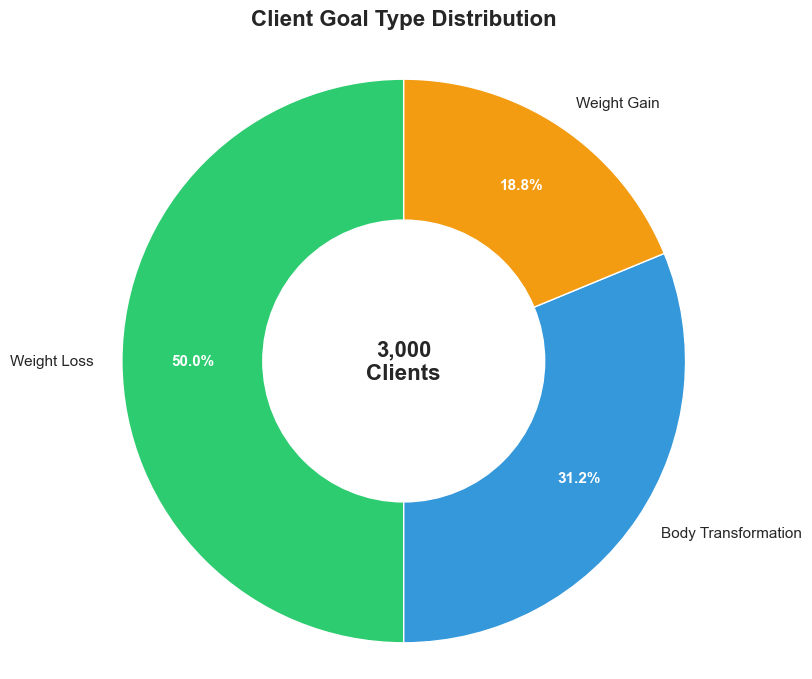

,Goal_Type,Client_Count,Percentage
0,Weight Loss,1500,50.0
1,Body Transformation,937,31.2
2,Weight Gain,563,18.8


In [2]:
# ============================================================
# Chart 1: Goal Type Distribution Donut Chart
# Business Question:
# What are the main goals clients join Get Fit with Drishti for?
# ============================================================

# ------------------------------------------------------------
# Step 1: Count clients by goal type
# ------------------------------------------------------------

# Count how many clients belong to each goal category
goal_counts = df["Goal_Type"].value_counts()

# Calculate each goal category as a percentage of total clients
goal_percentages = (goal_counts / goal_counts.sum() * 100).round(1)

# ------------------------------------------------------------
# Step 2: Create the donut chart
# ------------------------------------------------------------

# Create the chart canvas
fig, ax = plt.subplots(figsize=(8, 8), facecolor=BACKGROUND)

# Define colors for the goal categories
goal_colors = [PRIMARY, NEUTRAL, ACCENT]

# Create pie chart with percentage labels
wedges, texts, autotexts = ax.pie(
    goal_counts,
    labels=goal_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=goal_colors,
    pctdistance=0.75,
    textprops={"fontsize": 11}
)

# ------------------------------------------------------------
# Step 3: Add donut hole in the middle
# ------------------------------------------------------------

# Add a white circle in the center to turn the pie chart into a donut chart
center_circle = plt.Circle((0, 0), 0.50, fc=BACKGROUND)
ax.add_artist(center_circle)

# ------------------------------------------------------------
# Step 4: Improve text styling
# ------------------------------------------------------------

# Make percentage labels white and bold so they are easy to read
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(11)
    autotext.set_fontweight("bold")

# Add total client count in the middle of the donut
ax.text(
    0,
    0,
    f"{len(df):,}\nClients",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold"
)

# Add a clear chart title
ax.set_title(
    "Client Goal Type Distribution",
    fontsize=16,
    fontweight="bold",
    pad=20
)

# Keep the donut chart perfectly circular
ax.axis("equal")

# ------------------------------------------------------------
# Step 5: Save and display the chart
# ------------------------------------------------------------

# Save the chart as a PNG file inside 06_eda_charts
chart_path = charts_folder / "chart_01_goal_type_distribution.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=BACKGROUND
)

# Display the chart
plt.show()

# ------------------------------------------------------------
# Step 6: Show summary table
# ------------------------------------------------------------

# Create a small summary table for checking the numbers
goal_summary = pd.DataFrame({
    "Goal_Type": goal_counts.index,
    "Client_Count": goal_counts.values,
    "Percentage": goal_percentages.values
})

goal_summary

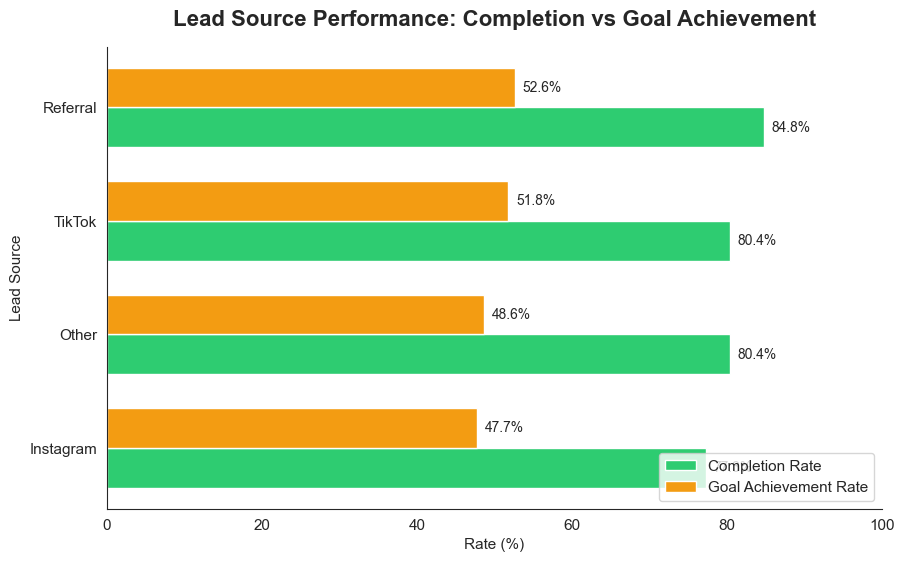

,Lead_Source,total_clients,completed_clients,goal_achieved_clients,Completion_Rate,Goal_Achievement_Rate
0,Instagram,476,368,227,77.3,47.7
1,Other,138,111,67,80.4,48.6
3,TikTok,1614,1297,836,80.4,51.8
2,Referral,772,655,406,84.8,52.6


In [3]:
# ============================================================
# Chart 2: Lead Source Performance
# Business Question:
# Which lead source brings clients with the strongest outcomes?
# ============================================================

# ------------------------------------------------------------
# Step 1: Create performance summary by lead source
# ------------------------------------------------------------

# Group clients by lead source and calculate business performance metrics
lead_source_summary = (
    df.groupby("Lead_Source")
    .agg(
        total_clients=("Client_ID", "count"),
        completed_clients=("Status", lambda x: (x == "Completed").sum()),
        goal_achieved_clients=("Goal_Achieved", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

# Calculate completion rate for each lead source
lead_source_summary["Completion_Rate"] = (
    lead_source_summary["completed_clients"] / lead_source_summary["total_clients"] * 100
).round(1)

# Calculate goal achievement rate for each lead source
lead_source_summary["Goal_Achievement_Rate"] = (
    lead_source_summary["goal_achieved_clients"] / lead_source_summary["total_clients"] * 100
).round(1)

# Sort lead sources by completion rate so strongest channels appear first
lead_source_summary = lead_source_summary.sort_values(
    by="Completion_Rate",
    ascending=True
)

# ------------------------------------------------------------
# Step 2: Prepare data for grouped horizontal bar chart
# ------------------------------------------------------------

# Set position for each lead source on the y-axis
y_positions = np.arange(len(lead_source_summary))

# Set bar height
bar_height = 0.35

# ------------------------------------------------------------
# Step 3: Create horizontal grouped bar chart
# ------------------------------------------------------------

# Create chart canvas
fig, ax = plt.subplots(figsize=(10, 6), facecolor=BACKGROUND)

# Completion rate bars
completion_bars = ax.barh(
    y_positions - bar_height / 2,
    lead_source_summary["Completion_Rate"],
    height=bar_height,
    color=PRIMARY,
    label="Completion Rate"
)

# Goal achievement rate bars
goal_bars = ax.barh(
    y_positions + bar_height / 2,
    lead_source_summary["Goal_Achievement_Rate"],
    height=bar_height,
    color=ACCENT,
    label="Goal Achievement Rate"
)

# ------------------------------------------------------------
# Step 4: Add data labels to bars
# ------------------------------------------------------------

# Add labels to completion rate bars
for bar in completion_bars:
    width = bar.get_width()
    ax.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=10
    )

# Add labels to goal achievement rate bars
for bar in goal_bars:
    width = bar.get_width()
    ax.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=10
    )

# ------------------------------------------------------------
# Step 5: Format chart
# ------------------------------------------------------------

# Add lead source labels on y-axis
ax.set_yticks(y_positions)
ax.set_yticklabels(lead_source_summary["Lead_Source"])

# Add x-axis label
ax.set_xlabel("Rate (%)", fontsize=11)

# Add y-axis label
ax.set_ylabel("Lead Source", fontsize=11)

# Add chart title
ax.set_title(
    "Lead Source Performance: Completion vs Goal Achievement",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Add legend
ax.legend(loc="lower right")

# Remove unnecessary chart borders for cleaner look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Set x-axis limit so labels fit nicely
ax.set_xlim(0, 100)

# Keep background clean
ax.set_facecolor(BACKGROUND)

# ------------------------------------------------------------
# Step 6: Save and display chart
# ------------------------------------------------------------

# Save chart inside 06_eda_charts folder
chart_path = charts_folder / "chart_02_lead_source_performance.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=BACKGROUND
)

# Display chart
plt.show()

# ------------------------------------------------------------
# Step 7: Show summary table
# ------------------------------------------------------------

lead_source_summary

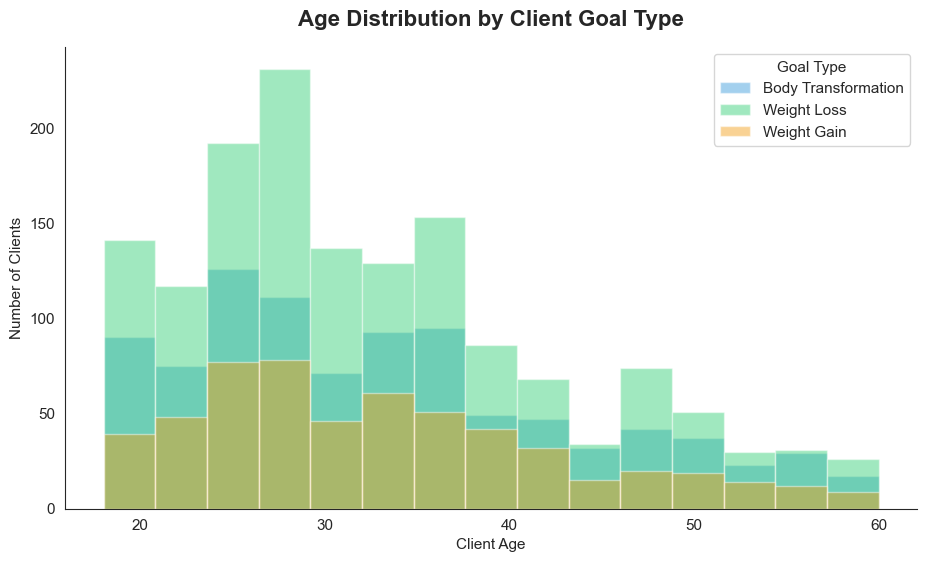

,Goal_Type,count,mean,median,min,max
0,Body Transformation,937,33.3,31.0,18,60
1,Weight Gain,563,33.1,31.0,18,60
2,Weight Loss,1500,32.7,30.0,18,60


In [4]:
# ============================================================
# Chart 3: Age Distribution by Goal Type
# Business Question:
# How are client ages distributed across different goal types?
# ============================================================

# ------------------------------------------------------------
# Step 1: Prepare goal type list and colors
# ------------------------------------------------------------

# Get goal types in a consistent order
goal_types = df["Goal_Type"].dropna().unique()

# Create color mapping for each goal type
goal_color_map = {
    "Weight Loss": PRIMARY,
    "Body Transformation": NEUTRAL,
    "Weight Gain": ACCENT
}

# ------------------------------------------------------------
# Step 2: Create histogram
# ------------------------------------------------------------

# Create chart canvas
fig, ax = plt.subplots(figsize=(11, 6), facecolor=BACKGROUND)

# Plot one transparent histogram for each goal type
for goal in goal_types:
    subset = df[df["Goal_Type"] == goal]
    
    ax.hist(
        subset["Age"],
        bins=15,
        alpha=0.45,
        label=goal,
        color=goal_color_map.get(goal, NEUTRAL),
        edgecolor="white"
    )

# ------------------------------------------------------------
# Step 3: Format chart
# ------------------------------------------------------------

# Add chart title
ax.set_title(
    "Age Distribution by Client Goal Type",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Add axis labels
ax.set_xlabel("Client Age", fontsize=11)
ax.set_ylabel("Number of Clients", fontsize=11)

# Add legend
ax.legend(title="Goal Type")

# Remove unnecessary chart borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Keep chart background clean
ax.set_facecolor(BACKGROUND)

# ------------------------------------------------------------
# Step 4: Save and display chart
# ------------------------------------------------------------

# Save chart inside 06_eda_charts folder
chart_path = charts_folder / "chart_03_age_distribution_by_goal_type.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=BACKGROUND
)

# Display chart
plt.show()

# ------------------------------------------------------------
# Step 5: Show age summary by goal type
# ------------------------------------------------------------

# Create a summary table showing age patterns by goal type
age_goal_summary = (
    df.groupby("Goal_Type")["Age"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(1)
    .reset_index()
)

age_goal_summary

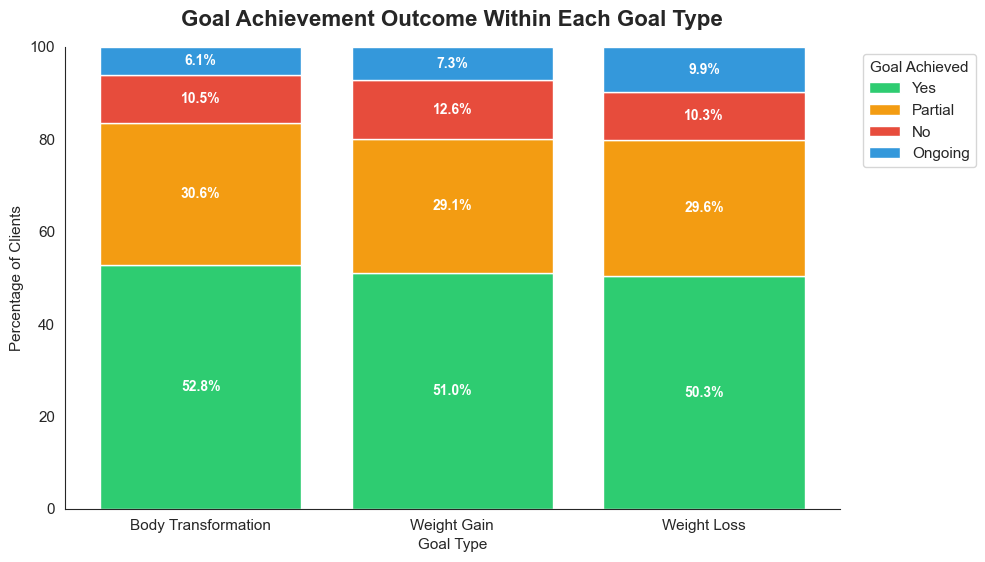

Goal_Achieved,Yes,Partial,No,Ongoing
Goal_Type,,,,
Body Transformation,52.8,30.6,10.5,6.1
Weight Gain,51.0,29.1,12.6,7.3
Weight Loss,50.3,29.6,10.3,9.9


In [5]:
# ============================================================
# Chart 4: Goal Achievement Within Each Goal Type
# Business Question:
# Which client goal type has the strongest success outcome?
# ============================================================

# ------------------------------------------------------------
# Step 1: Create count table for Goal Type vs Goal Achieved
# ------------------------------------------------------------

# Create a cross-tab table showing how many clients fall into each goal achievement category
goal_achievement_counts = pd.crosstab(
    df["Goal_Type"],
    df["Goal_Achieved"]
)

# Set a clear order for goal achievement categories
achievement_order = ["Yes", "Partial", "No", "Ongoing"]

# Keep only columns that exist in the dataset, in the correct order
achievement_order = [col for col in achievement_order if col in goal_achievement_counts.columns]

# Reorder the columns
goal_achievement_counts = goal_achievement_counts[achievement_order]

# ------------------------------------------------------------
# Step 2: Convert counts into row percentages
# ------------------------------------------------------------

# Convert each row into percentages so goal types can be compared fairly
goal_achievement_pct = goal_achievement_counts.div(
    goal_achievement_counts.sum(axis=1),
    axis=0
) * 100

# ------------------------------------------------------------
# Step 3: Create stacked bar chart
# ------------------------------------------------------------

# Create chart canvas
fig, ax = plt.subplots(figsize=(10, 6), facecolor=BACKGROUND)

# Define colors for each achievement category
achievement_colors = {
    "Yes": PRIMARY,
    "Partial": ACCENT,
    "No": WARNING,
    "Ongoing": NEUTRAL
}

# Track where each stacked section should start
bottom_values = np.zeros(len(goal_achievement_pct))

# Create one stacked bar section for each achievement category
for achievement in achievement_order:
    bars = ax.bar(
        goal_achievement_pct.index,
        goal_achievement_pct[achievement],
        bottom=bottom_values,
        label=achievement,
        color=achievement_colors.get(achievement, NEUTRAL)
    )
    
    # Add percentage labels inside each bar section
    for i, bar in enumerate(bars):
        height = bar.get_height()
        
        # Only label sections large enough to read clearly
        if height >= 5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom_values[i] + height / 2,
                f"{height:.1f}%",
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold",
                color="white"
            )
    
    # Update bottom position for the next stacked section
    bottom_values += goal_achievement_pct[achievement].values

# ------------------------------------------------------------
# Step 4: Format chart
# ------------------------------------------------------------

# Add chart title
ax.set_title(
    "Goal Achievement Outcome Within Each Goal Type",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Add axis labels
ax.set_xlabel("Goal Type", fontsize=11)
ax.set_ylabel("Percentage of Clients", fontsize=11)

# Keep y-axis from 0 to 100 because this is a percentage stacked chart
ax.set_ylim(0, 100)

# Add legend
ax.legend(title="Goal Achieved", bbox_to_anchor=(1.02, 1), loc="upper left")

# Remove unnecessary chart borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Keep background clean
ax.set_facecolor(BACKGROUND)

# ------------------------------------------------------------
# Step 5: Save and display chart
# ------------------------------------------------------------

# Save chart inside 06_eda_charts folder
chart_path = charts_folder / "chart_04_goal_achievement_by_goal_type.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=BACKGROUND
)

# Display chart
plt.show()

# ------------------------------------------------------------
# Step 6: Show summary percentage table
# ------------------------------------------------------------

goal_achievement_pct.round(1)

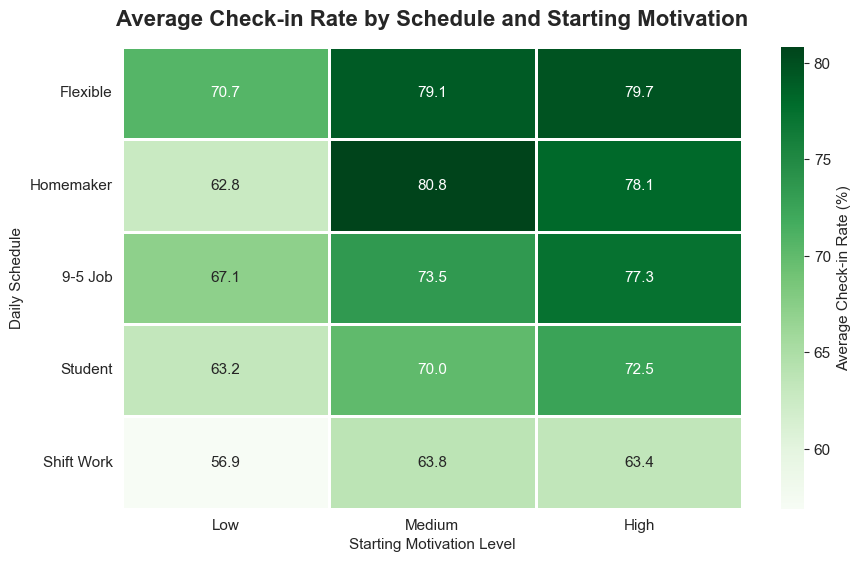

Motivation_Level_Start,Low,Medium,High
Daily_Schedule,,,
Flexible,70.7,79.1,79.7
Homemaker,62.8,80.8,78.1
9-5 Job,67.1,73.5,77.3
Student,63.2,70.0,72.5
Shift Work,56.9,63.8,63.4


In [6]:
# ============================================================
# Chart 5: Check-in Rate Heatmap
# Business Question:
# Which daily schedule and starting motivation groups engage most consistently?
# ============================================================

# ------------------------------------------------------------
# Step 1: Create pivot table for heatmap
# ------------------------------------------------------------

# Create a table showing average check-in rate by daily schedule and motivation level
checkin_heatmap_data = df.pivot_table(
    values="Checkin_Rate_Pct",
    index="Daily_Schedule",
    columns="Motivation_Level_Start",
    aggfunc="mean"
)

# ------------------------------------------------------------
# Step 2: Reorder columns and rows for better storytelling
# ------------------------------------------------------------

# Set motivation levels in a logical order
motivation_order = ["Low", "Medium", "High"]

# Keep only motivation columns that exist in the dataset
motivation_order = [col for col in motivation_order if col in checkin_heatmap_data.columns]

# Reorder motivation columns
checkin_heatmap_data = checkin_heatmap_data[motivation_order]

# Sort schedules by highest average check-in rate
schedule_order = (
    checkin_heatmap_data.mean(axis=1)
    .sort_values(ascending=False)
    .index
)

# Apply schedule order
checkin_heatmap_data = checkin_heatmap_data.loc[schedule_order]

# ------------------------------------------------------------
# Step 3: Create heatmap
# ------------------------------------------------------------

# Create chart canvas
fig, ax = plt.subplots(figsize=(10, 6), facecolor=BACKGROUND)

# Create heatmap with annotated average check-in rates
sns.heatmap(
    checkin_heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Greens",
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "Average Check-in Rate (%)"},
    ax=ax
)

# ------------------------------------------------------------
# Step 4: Format chart
# ------------------------------------------------------------

# Add chart title
ax.set_title(
    "Average Check-in Rate by Schedule and Starting Motivation",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Add axis labels
ax.set_xlabel("Starting Motivation Level", fontsize=11)
ax.set_ylabel("Daily Schedule", fontsize=11)

# Keep labels readable
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)

# ------------------------------------------------------------
# Step 5: Save and display chart
# ------------------------------------------------------------

# Save chart inside 06_eda_charts folder
chart_path = charts_folder / "chart_05_checkin_rate_heatmap.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=BACKGROUND
)

# Display chart
plt.show()

# ------------------------------------------------------------
# Step 6: Show summary table
# ------------------------------------------------------------

checkin_heatmap_data.round(1)

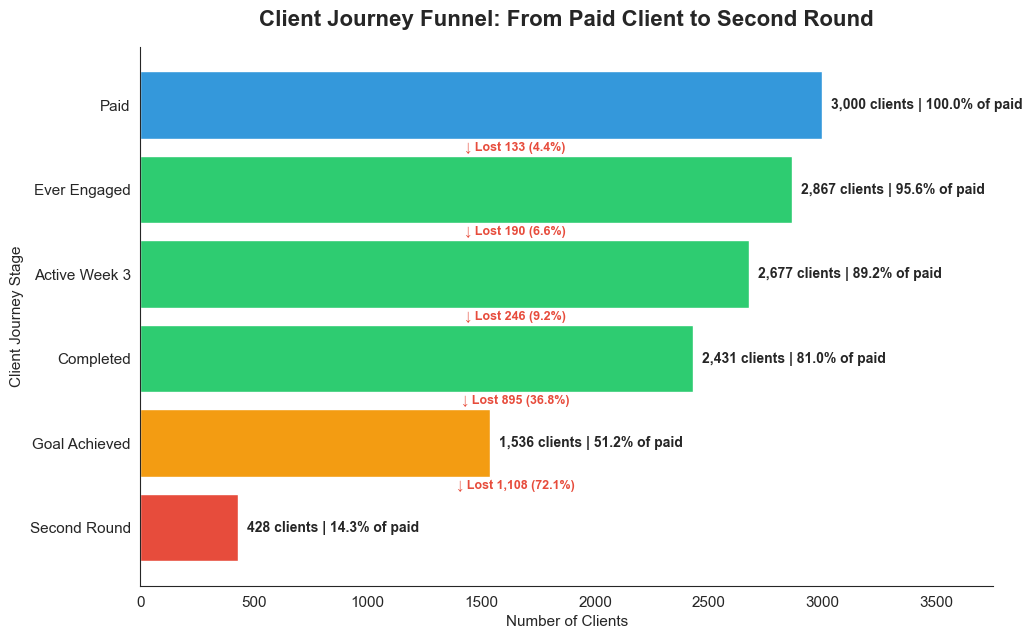

,Stage,Client_Count,Pct_of_Paid,Drop_From_Previous,Drop_Pct_From_Previous
0,Paid,3000,100.0,0,0.0
1,Ever Engaged,2867,95.6,133,4.4
2,Active Week 3,2677,89.2,190,6.6
3,Completed,2431,81.0,246,9.2
4,Goal Achieved,1536,51.2,895,36.8
5,Second Round,428,14.3,1108,72.1


In [8]:
# ============================================================
# Chart 6: Client Journey Funnel
# Business Question:
# Where are clients dropping off in the full customer journey?
# ============================================================

# ------------------------------------------------------------
# Step 1: Calculate client count at each funnel stage
# ------------------------------------------------------------

# Total paid clients
paid_clients = len(df)

# Clients who engaged at least once
ever_engaged_clients = df[df["Ever_Engaged"] == True].shape[0]

# Clients who were still active at week 3
active_week3_clients = df[df["Week3_Still_Active"] == "Yes"].shape[0]

# Clients who completed the program
completed_clients = df[df["Status"] == "Completed"].shape[0]

# Clients who fully achieved their goal
goal_achieved_clients = df[df["Goal_Achieved"] == "Yes"].shape[0]

# Clients who signed up for a second round
second_round_clients = df[df["Second_Round"] == "Yes"].shape[0]

# ------------------------------------------------------------
# Step 2: Create funnel dataframe
# ------------------------------------------------------------

# Store funnel stages and client counts in a dataframe
funnel_df = pd.DataFrame({
    "Stage": [
        "Paid",
        "Ever Engaged",
        "Active Week 3",
        "Completed",
        "Goal Achieved",
        "Second Round"
    ],
    "Client_Count": [
        paid_clients,
        ever_engaged_clients,
        active_week3_clients,
        completed_clients,
        goal_achieved_clients,
        second_round_clients
    ]
})

# Calculate percentage of original paid clients remaining at each stage
funnel_df["Pct_of_Paid"] = (
    funnel_df["Client_Count"] / paid_clients * 100
).round(1)

# Calculate how many clients were lost from the previous stage
funnel_df["Drop_From_Previous"] = (
    funnel_df["Client_Count"].shift(1) - funnel_df["Client_Count"]
)

# Calculate percentage drop from the previous stage
funnel_df["Drop_Pct_From_Previous"] = (
    funnel_df["Drop_From_Previous"] / funnel_df["Client_Count"].shift(1) * 100
).round(1)

# Replace missing drop values in the first row with 0
funnel_df["Drop_From_Previous"] = funnel_df["Drop_From_Previous"].fillna(0).astype(int)
funnel_df["Drop_Pct_From_Previous"] = funnel_df["Drop_Pct_From_Previous"].fillna(0)

# ------------------------------------------------------------
# Step 3: Create funnel-style horizontal bar chart
# ------------------------------------------------------------

# Create chart canvas
fig, ax = plt.subplots(figsize=(11, 7), facecolor=BACKGROUND)

# Create horizontal bars
bars = ax.barh(
    funnel_df["Stage"],
    funnel_df["Client_Count"],
    color=[NEUTRAL, PRIMARY, PRIMARY, PRIMARY, ACCENT, WARNING]
)

# Reverse y-axis so Paid appears at the top
ax.invert_yaxis()

# ------------------------------------------------------------
# Step 4: Add labels to each funnel bar
# ------------------------------------------------------------

# Add count and percentage labels to each bar
for i, bar in enumerate(bars):
    width = bar.get_width()
    
    label_text = (
        f"{int(width):,} clients | "
        f"{funnel_df.loc[i, 'Pct_of_Paid']}% of paid"
    )
    
    ax.text(
        width + 40,
        bar.get_y() + bar.get_height() / 2,
        label_text,
        va="center",
        fontsize=10,
        fontweight="bold"
    )

# Add drop-off labels between stages
for i in range(1, len(funnel_df)):
    drop_count = funnel_df.loc[i, "Drop_From_Previous"]
    drop_pct = funnel_df.loc[i, "Drop_Pct_From_Previous"]
    
    ax.text(
        paid_clients * 0.55,
        i - 0.5,
        f"↓ Lost {drop_count:,} ({drop_pct}%)",
        ha="center",
        va="center",
        fontsize=9,
        color=WARNING,
        fontweight="bold"
    )

# ------------------------------------------------------------
# Step 5: Format chart
# ------------------------------------------------------------

# Add chart title
ax.set_title(
    "Client Journey Funnel: From Paid Client to Second Round",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Add axis labels
ax.set_xlabel("Number of Clients", fontsize=11)
ax.set_ylabel("Client Journey Stage", fontsize=11)

# Remove unnecessary chart borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Keep chart background clean
ax.set_facecolor(BACKGROUND)

# Add extra space on the right for labels
ax.set_xlim(0, paid_clients * 1.25)

# ------------------------------------------------------------
# Step 6: Save and display chart
# ------------------------------------------------------------

# Save chart inside 06_eda_charts folder
chart_path = charts_folder / "chart_06_client_journey_funnel.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=BACKGROUND
)

# Display chart
plt.show()

# ------------------------------------------------------------
# Step 7: Show funnel summary table
# ------------------------------------------------------------

funnel_df

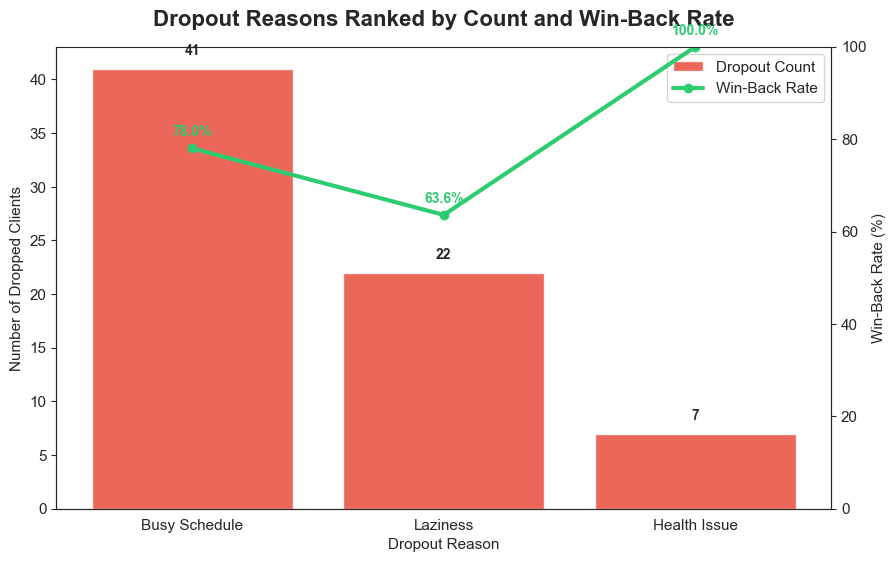

,Dropout_Reason,dropout_count,returned_clients,Win_Back_Rate
0,Busy Schedule,41,32,78.0
2,Laziness,22,14,63.6
1,Health Issue,7,7,100.0


In [9]:
# ============================================================
# Chart 7: Dropout Reasons and Win-Back Rate
# Business Question:
# Which dropout reasons happen most often, and which are most recoverable?
# ============================================================

# ------------------------------------------------------------
# Step 1: Filter only clients who dropped out
# ------------------------------------------------------------

# Keep only rows where Dropout_Reason is not "N/A"
dropout_df = df[df["Dropout_Reason"] != "N/A"].copy()

# ------------------------------------------------------------
# Step 2: Create dropout reason summary
# ------------------------------------------------------------

# Group by dropout reason and calculate dropout count + returned count
dropout_summary = (
    dropout_df.groupby("Dropout_Reason")
    .agg(
        dropout_count=("Client_ID", "count"),
        returned_clients=("Returned_After_Drop", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

# Calculate win-back rate for each dropout reason
dropout_summary["Win_Back_Rate"] = (
    dropout_summary["returned_clients"] / dropout_summary["dropout_count"] * 100
).round(1)

# Sort reasons by highest dropout count
dropout_summary = dropout_summary.sort_values(
    by="dropout_count",
    ascending=False
)

# ------------------------------------------------------------
# Step 3: Create bar chart with second-axis line
# ------------------------------------------------------------

# Create chart canvas
fig, ax1 = plt.subplots(figsize=(10, 6), facecolor=BACKGROUND)

# Create bars for dropout count
bars = ax1.bar(
    dropout_summary["Dropout_Reason"],
    dropout_summary["dropout_count"],
    color=WARNING,
    alpha=0.85,
    label="Dropout Count"
)

# ------------------------------------------------------------
# Step 4: Add labels on bars
# ------------------------------------------------------------

# Add dropout count labels on top of each bar
for bar in bars:
    height = bar.get_height()
    
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# ------------------------------------------------------------
# Step 5: Add win-back rate line on second axis
# ------------------------------------------------------------

# Create second y-axis
ax2 = ax1.twinx()

# Plot win-back rate line
ax2.plot(
    dropout_summary["Dropout_Reason"],
    dropout_summary["Win_Back_Rate"],
    color=PRIMARY,
    marker="o",
    linewidth=3,
    label="Win-Back Rate"
)

# Add labels to win-back rate points
for i, rate in enumerate(dropout_summary["Win_Back_Rate"]):
    ax2.text(
        i,
        rate + 2,
        f"{rate:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=PRIMARY
    )

# ------------------------------------------------------------
# Step 6: Format chart
# ------------------------------------------------------------

# Add chart title
ax1.set_title(
    "Dropout Reasons Ranked by Count and Win-Back Rate",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Add axis labels
ax1.set_xlabel("Dropout Reason", fontsize=11)
ax1.set_ylabel("Number of Dropped Clients", fontsize=11)
ax2.set_ylabel("Win-Back Rate (%)", fontsize=11)

# Set second y-axis from 0 to 100 because win-back rate is a percentage
ax2.set_ylim(0, 100)

# Remove unnecessary borders from first axis
ax1.spines["top"].set_visible(False)

# Keep chart background clean
ax1.set_facecolor(BACKGROUND)

# Rotate x-axis labels slightly if needed
ax1.tick_params(axis="x", rotation=0)

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper right"
)

# ------------------------------------------------------------
# Step 7: Save and display chart
# ------------------------------------------------------------

# Save chart inside 06_eda_charts folder
chart_path = charts_folder / "chart_07_dropout_reasons_winback_rate.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=BACKGROUND
)

# Display chart
plt.show()

# ------------------------------------------------------------
# Step 8: Show summary table
# ------------------------------------------------------------

dropout_summary

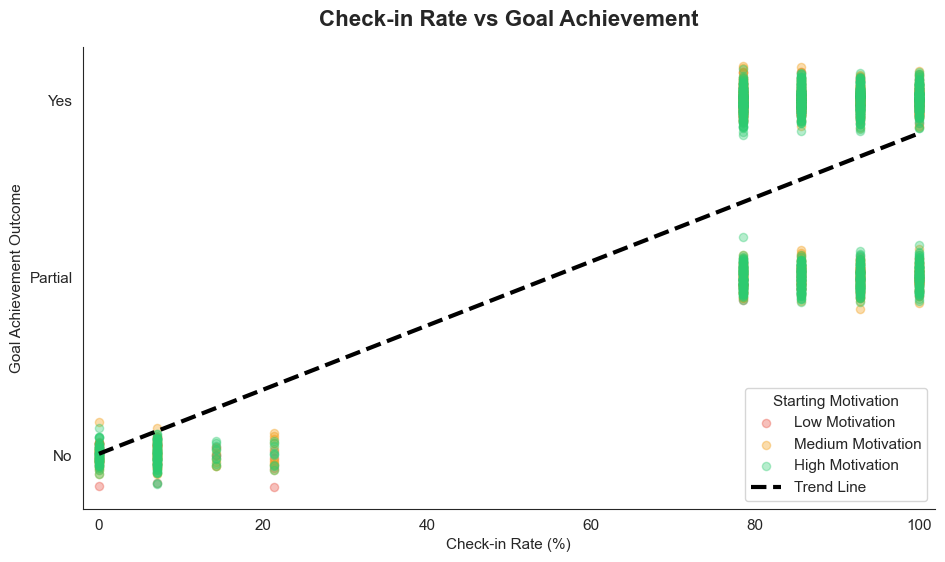

,Goal_Achieved,count,mean,median,min,max
0,No,323,5.8,7.1,0.0,21.4
1,Partial,895,89.3,92.9,78.6,100.0
2,Yes,1536,89.1,85.7,78.6,100.0


In [10]:
# ============================================================
# Chart 8: Check-in Rate vs Goal Achievement
# Business Question:
# Does stronger client engagement lead to better goal achievement?
# ============================================================

# ------------------------------------------------------------
# Step 1: Prepare data for scatter plot
# ------------------------------------------------------------

# Keep only clients with final goal outcomes: Yes, Partial, or No
# Ongoing clients are removed because their final result is not complete yet
engagement_df = df[df["Goal_Achieved"].isin(["Yes", "Partial", "No"])].copy()

# Convert goal achievement categories into numeric success scores
goal_score_map = {
    "No": 0,
    "Partial": 0.5,
    "Yes": 1
}

# Create numeric goal achievement score column
engagement_df["Goal_Achievement_Score"] = engagement_df["Goal_Achieved"].map(goal_score_map)

# ------------------------------------------------------------
# Step 2: Add small random jitter to y-values
# ------------------------------------------------------------

# Jitter prevents dots from sitting exactly on top of each other
# This makes the scatter plot easier to read
np.random.seed(42)
engagement_df["Goal_Achievement_Jitter"] = (
    engagement_df["Goal_Achievement_Score"] 
    + np.random.normal(0, 0.03, size=len(engagement_df))
)

# ------------------------------------------------------------
# Step 3: Create scatter plot
# ------------------------------------------------------------

# Create chart canvas
fig, ax = plt.subplots(figsize=(11, 6), facecolor=BACKGROUND)

# Define colors for motivation level
motivation_color_map = {
    "Low": WARNING,
    "Medium": ACCENT,
    "High": PRIMARY
}

# Plot points separately by starting motivation level
for motivation_level, color in motivation_color_map.items():
    subset = engagement_df[
        engagement_df["Motivation_Level_Start"] == motivation_level
    ]
    
    ax.scatter(
        subset["Checkin_Rate_Pct"],
        subset["Goal_Achievement_Jitter"],
        alpha=0.35,
        s=35,
        color=color,
        label=f"{motivation_level} Motivation"
    )

# ------------------------------------------------------------
# Step 4: Add trend line
# ------------------------------------------------------------

# Fit a simple trend line between check-in rate and goal achievement score
x = engagement_df["Checkin_Rate_Pct"]
y = engagement_df["Goal_Achievement_Score"]

trend_coefficients = np.polyfit(x, y, 1)
trend_line = np.poly1d(trend_coefficients)

# Create x values for trend line
x_trend = np.linspace(x.min(), x.max(), 100)

# Plot trend line
ax.plot(
    x_trend,
    trend_line(x_trend),
    color="black",
    linewidth=3,
    linestyle="--",
    label="Trend Line"
)

# ------------------------------------------------------------
# Step 5: Format chart
# ------------------------------------------------------------

# Add chart title
ax.set_title(
    "Check-in Rate vs Goal Achievement",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Add axis labels
ax.set_xlabel("Check-in Rate (%)", fontsize=11)
ax.set_ylabel("Goal Achievement Outcome", fontsize=11)

# Replace numeric y-axis values with readable labels
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels(["No", "Partial", "Yes"])

# Keep chart within clean limits
ax.set_xlim(-2, 102)
ax.set_ylim(-0.15, 1.15)

# Add legend
ax.legend(title="Starting Motivation", loc="lower right")

# Remove unnecessary chart borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Keep background clean
ax.set_facecolor(BACKGROUND)

# ------------------------------------------------------------
# Step 6: Save and display chart
# ------------------------------------------------------------

# Save chart inside 06_eda_charts folder
chart_path = charts_folder / "chart_08_checkin_rate_vs_goal_achievement.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=BACKGROUND
)

# Display chart
plt.show()

# ------------------------------------------------------------
# Step 7: Show summary table
# ------------------------------------------------------------

# Calculate average check-in rate by goal achievement outcome
checkin_success_summary = (
    engagement_df.groupby("Goal_Achieved")["Checkin_Rate_Pct"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(1)
    .reset_index()
)

checkin_success_summary

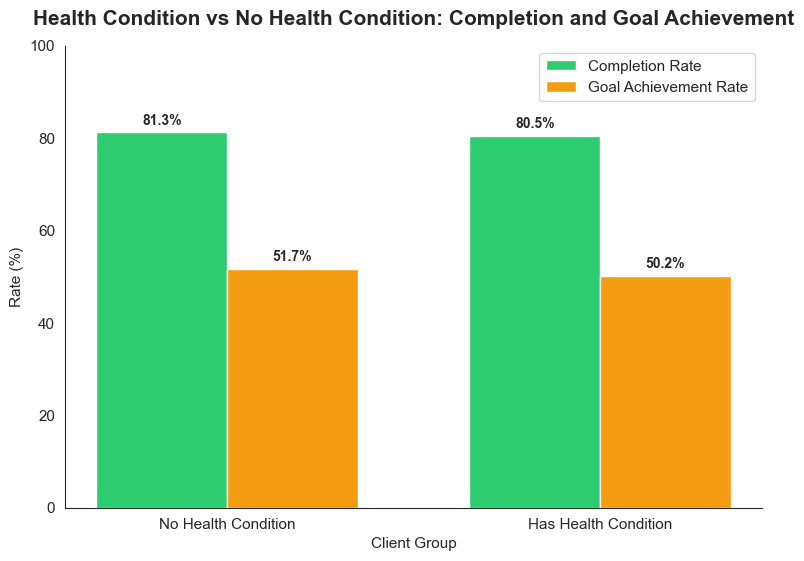

,Health_Condition_Group,total_clients,completed_clients,goal_achieved_clients,Completion_Rate,Goal_Achievement_Rate
1,No Health Condition,1931,1570,999,81.3,51.7
0,Has Health Condition,1069,861,537,80.5,50.2


In [13]:
# ============================================================
# Chart 9: Health Condition vs No Health Condition
# Business Question:
# Do clients with health conditions complete and achieve goals at the same rate?
# ============================================================

# ------------------------------------------------------------
# Step 1: Create health condition group
# ------------------------------------------------------------

# Create a new column that separates clients into:
# 1. No Health Condition = Health_Condition is missing/blank
# 2. Has Health Condition = Health_Condition has a condition name
df["Health_Condition_Group"] = np.where(
    df["Health_Condition"].isna(),
    "No Health Condition",
    "Has Health Condition"
)

# ------------------------------------------------------------
# Step 2: Create summary table
# ------------------------------------------------------------

# Group clients by health condition group and calculate key success metrics
health_summary = (
    df.groupby("Health_Condition_Group")
    .agg(
        total_clients=("Client_ID", "count"),
        completed_clients=("Status", lambda x: (x == "Completed").sum()),
        goal_achieved_clients=("Goal_Achieved", lambda x: (x == "Yes").sum())
    )
    .reset_index()
)

# Calculate completion rate for each group
health_summary["Completion_Rate"] = (
    health_summary["completed_clients"] / health_summary["total_clients"] * 100
).round(1)

# Calculate goal achievement rate for each group
health_summary["Goal_Achievement_Rate"] = (
    health_summary["goal_achieved_clients"] / health_summary["total_clients"] * 100
).round(1)

# Sort groups in a clear order
health_summary["Health_Condition_Group"] = pd.Categorical(
    health_summary["Health_Condition_Group"],
    categories=["No Health Condition", "Has Health Condition"],
    ordered=True
)

health_summary = health_summary.sort_values("Health_Condition_Group")

# ------------------------------------------------------------
# Step 3: Prepare grouped bar chart
# ------------------------------------------------------------

# Set x-axis positions
x_positions = np.arange(len(health_summary))

# Set bar width
bar_width = 0.35

# Create chart canvas
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BACKGROUND)

# Create completion rate bars
completion_bars = ax.bar(
    x_positions - bar_width / 2,
    health_summary["Completion_Rate"],
    width=bar_width,
    color=PRIMARY,
    label="Completion Rate"
)

# Create goal achievement rate bars
goal_bars = ax.bar(
    x_positions + bar_width / 2,
    health_summary["Goal_Achievement_Rate"],
    width=bar_width,
    color=ACCENT,
    label="Goal Achievement Rate"
)

# ------------------------------------------------------------
# Step 4: Add labels on bars
# ------------------------------------------------------------

# Add percentage labels to completion bars
for bar in completion_bars:
    height = bar.get_height()
    
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Add percentage labels to goal achievement bars
for bar in goal_bars:
    height = bar.get_height()
    
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# ------------------------------------------------------------
# Step 5: Format chart
# ------------------------------------------------------------

# Add chart title
ax.set_title(
    "Health Condition vs No Health Condition: Completion and Goal Achievement",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# Add axis labels
ax.set_xlabel("Client Group", fontsize=11)
ax.set_ylabel("Rate (%)", fontsize=11)

# Add x-axis group labels
ax.set_xticks(x_positions)
ax.set_xticklabels(health_summary["Health_Condition_Group"])

# Set y-axis limit
ax.set_ylim(0, 100)

# Add legend
ax.legend(loc="upper right")

# Remove unnecessary chart borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Keep background clean
ax.set_facecolor(BACKGROUND)

# ------------------------------------------------------------
# Step 6: Save and display chart
# ------------------------------------------------------------

# Save chart inside 06_eda_charts folder
chart_path = charts_folder / "chart_09_health_condition_performance.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=BACKGROUND
)

# Display chart
plt.show()

# ------------------------------------------------------------
# Step 7: Show summary table
# ------------------------------------------------------------

health_summary

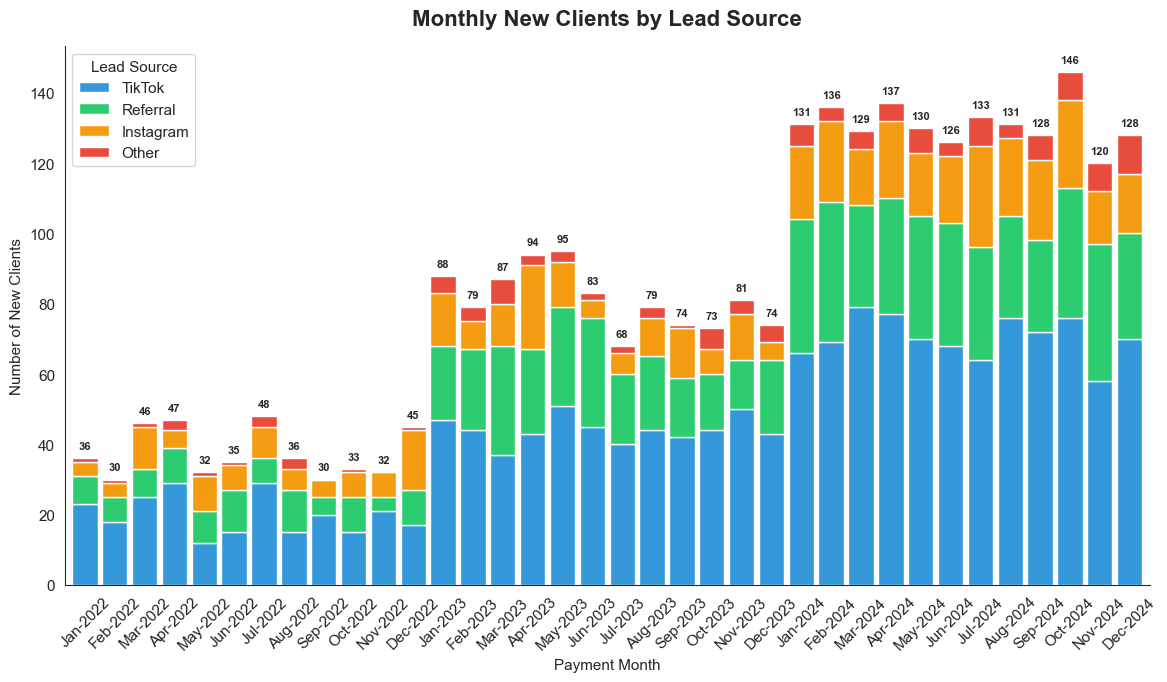

Lead_Source,TikTok,Referral,Instagram,Other
Payment_Month,,,,
Jan-2024,66.0,38.0,21.0,6.0
Feb-2024,69.0,40.0,23.0,4.0
Mar-2024,79.0,29.0,16.0,5.0
Apr-2024,77.0,33.0,22.0,5.0
May-2024,70.0,35.0,18.0,7.0
Jun-2024,68.0,35.0,19.0,4.0
Jul-2024,64.0,32.0,29.0,8.0
Aug-2024,76.0,29.0,22.0,4.0
Sep-2024,72.0,26.0,23.0,7.0


In [16]:
# ============================================================
# Chart 10: Monthly New Clients by Lead Source
# Business Question:
# How are monthly new clients growing by lead source over time?
# ============================================================

# ------------------------------------------------------------
# Step 1: Make sure Payment_Date is in datetime format
# ------------------------------------------------------------

# Convert Payment_Date into datetime format
# dayfirst=True is used because the original date format is DD/MM/YYYY
df["Payment_Date"] = pd.to_datetime(
    df["Payment_Date"],
    dayfirst=True,
    errors="coerce"
)

# ------------------------------------------------------------
# Step 2: Create month column
# ------------------------------------------------------------

# Create a month label like Jan-2022, Feb-2022, etc.
df["Payment_Month"] = df["Payment_Date"].dt.strftime("%b-%Y")

# Create a month sort column so months stay in correct timeline order
df["Payment_Month_Sort"] = df["Payment_Date"].dt.to_period("M")

# ------------------------------------------------------------
# Step 3: Count monthly new clients by lead source
# ------------------------------------------------------------

# Count number of clients by month and lead source
monthly_leads = (
    df.groupby(["Payment_Month_Sort", "Payment_Month", "Lead_Source"])
    .size()
    .reset_index(name="Client_Count")
)

# Sort by real month order
monthly_leads = monthly_leads.sort_values("Payment_Month_Sort")

# Pivot the table so each lead source becomes a separate column
monthly_leads_pivot = monthly_leads.pivot_table(
    index="Payment_Month",
    columns="Lead_Source",
    values="Client_Count",
    aggfunc="sum"
).fillna(0)

# Reorder the month labels based on actual month order
month_order = (
    monthly_leads[["Payment_Month_Sort", "Payment_Month"]]
    .drop_duplicates()
    .sort_values("Payment_Month_Sort")["Payment_Month"]
)

monthly_leads_pivot = monthly_leads_pivot.loc[month_order]

# ------------------------------------------------------------
# Step 4: Set lead source order and colors
# ------------------------------------------------------------

# Set clear order for lead sources
lead_source_order = ["TikTok", "Referral", "Instagram", "Other"]

# Keep only lead source columns that exist in the dataset
lead_source_order = [
    source for source in lead_source_order
    if source in monthly_leads_pivot.columns
]

# Reorder columns
monthly_leads_pivot = monthly_leads_pivot[lead_source_order]

# Define colors for each lead source
lead_source_colors = {
    "TikTok": NEUTRAL,
    "Referral": PRIMARY,
    "Instagram": ACCENT,
    "Other": WARNING
}

# Create color list in same order as lead sources
colors = [lead_source_colors[source] for source in lead_source_order]

# ------------------------------------------------------------
# Step 5: Create stacked bar chart
# ------------------------------------------------------------

# Create chart canvas
fig, ax = plt.subplots(figsize=(14, 7), facecolor=BACKGROUND)

# Create stacked monthly bar chart
monthly_leads_pivot.plot(
    kind="bar",
    stacked=True,
    color=colors,
    ax=ax,
    width=0.85
)

# ------------------------------------------------------------
# Step 6: Add total client labels on top of bars
# ------------------------------------------------------------

# Calculate total clients per month
monthly_totals = monthly_leads_pivot.sum(axis=1)

# Add total labels above each stacked bar
for i, total in enumerate(monthly_totals):
    ax.text(
        i,
        total + 2,
        int(total),
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold"
    )

# ------------------------------------------------------------
# Step 7: Format chart
# ------------------------------------------------------------

# Add chart title
ax.set_title(
    "Monthly New Clients by Lead Source",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Add axis labels
ax.set_xlabel("Payment Month", fontsize=11)
ax.set_ylabel("Number of New Clients", fontsize=11)

# Rotate month labels for readability
ax.tick_params(axis="x", rotation=45)

# Add legend
ax.legend(
    title="Lead Source",
    loc="upper left"
)

# Remove unnecessary chart borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Keep background clean
ax.set_facecolor(BACKGROUND)

# ------------------------------------------------------------
# Step 8: Save and display chart
# ------------------------------------------------------------

# Save chart inside 06_eda_charts folder
chart_path = charts_folder / "chart_10_monthly_new_clients_by_lead_source.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=BACKGROUND
)

# Display chart
plt.show()

# ------------------------------------------------------------
# Step 9: Show monthly summary table
# ------------------------------------------------------------

monthly_leads_pivot.tail(12)

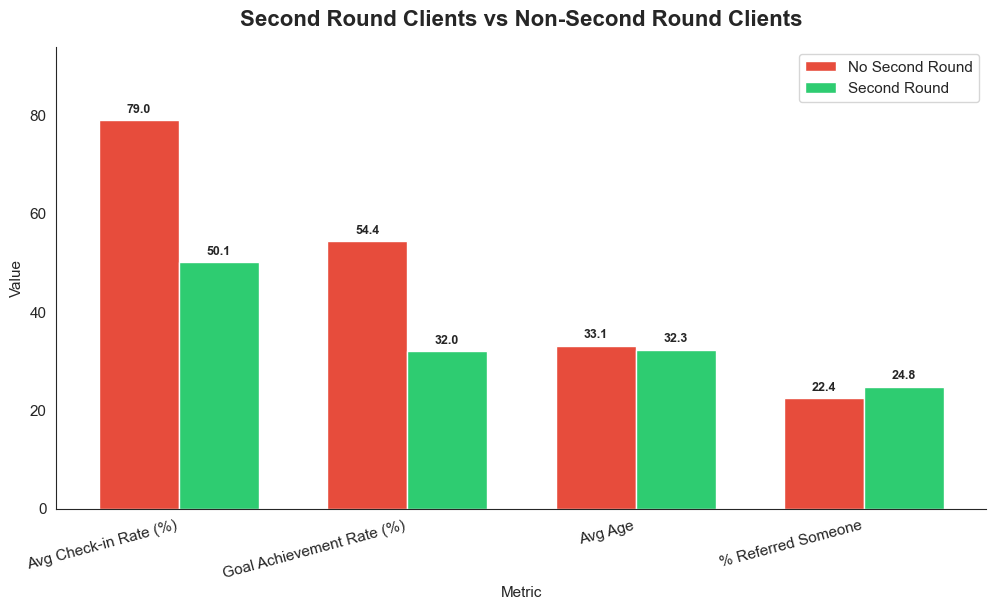

,Second_Round,total_clients,avg_checkin_rate,goal_achievement_rate,avg_age,referred_someone_rate
0,No,2572,79.0,54.4,33.1,22.4
1,Yes,428,50.1,32.0,32.3,24.8


In [18]:
# ============================================================
# Chart 11: Second Round Clients vs Non-Second Round Clients
# Business Question:
# What makes clients come back for another round?
# ============================================================

# ------------------------------------------------------------
# Step 1: Create "referred someone" flag
# ------------------------------------------------------------

# A client referred someone if their Client_ID appears in another client's Referred_By column
referred_client_ids = df["Referred_By"].dropna().unique()

# Create flag showing whether each client referred at least one other client
df["Referred_Someone"] = df["Client_ID"].isin(referred_client_ids)

# ------------------------------------------------------------
# Step 2: Create summary table by Second_Round
# ------------------------------------------------------------

# Group clients by whether they signed up for a second round
second_round_summary = (
    df.groupby("Second_Round")
    .agg(
        total_clients=("Client_ID", "count"),
        avg_checkin_rate=("Checkin_Rate_Pct", "mean"),
        goal_achievement_rate=("Goal_Achieved", lambda x: (x == "Yes").mean() * 100),
        avg_age=("Age", "mean"),
        referred_someone_rate=("Referred_Someone", lambda x: x.mean() * 100)
    )
    .reset_index()
)

# Round values
second_round_summary["avg_checkin_rate"] = second_round_summary["avg_checkin_rate"].round(1)
second_round_summary["goal_achievement_rate"] = second_round_summary["goal_achievement_rate"].round(1)
second_round_summary["avg_age"] = second_round_summary["avg_age"].round(1)
second_round_summary["referred_someone_rate"] = second_round_summary["referred_someone_rate"].round(1)

# Sort so No comes first, Yes comes second
second_round_summary["Second_Round"] = pd.Categorical(
    second_round_summary["Second_Round"],
    categories=["No", "Yes"],
    ordered=True
)

second_round_summary = second_round_summary.sort_values("Second_Round")

# ------------------------------------------------------------
# Step 3: Prepare data for chart
# ------------------------------------------------------------

# Convert table into long format for plotting
second_round_long = second_round_summary.melt(
    id_vars="Second_Round",
    value_vars=[
        "avg_checkin_rate",
        "goal_achievement_rate",
        "avg_age",
        "referred_someone_rate"
    ],
    var_name="Metric",
    value_name="Value"
)

# Rename metric labels
metric_name_map = {
    "avg_checkin_rate": "Avg Check-in Rate (%)",
    "goal_achievement_rate": "Goal Achievement Rate (%)",
    "avg_age": "Avg Age",
    "referred_someone_rate": "% Referred Someone"
}

second_round_long["Metric"] = second_round_long["Metric"].map(metric_name_map)

# ------------------------------------------------------------
# Step 4: Create grouped bar chart
# ------------------------------------------------------------

# Create chart canvas
fig, ax = plt.subplots(figsize=(12, 6), facecolor=BACKGROUND)

# Set x-axis positions
metrics = second_round_long["Metric"].unique()
x_positions = np.arange(len(metrics))
bar_width = 0.35

# Separate values for No and Yes groups
no_values = second_round_long[
    second_round_long["Second_Round"] == "No"
]["Value"].values

yes_values = second_round_long[
    second_round_long["Second_Round"] == "Yes"
]["Value"].values

# Create bars
no_bars = ax.bar(
    x_positions - bar_width / 2,
    no_values,
    width=bar_width,
    color=WARNING,
    label="No Second Round"
)

yes_bars = ax.bar(
    x_positions + bar_width / 2,
    yes_values,
    width=bar_width,
    color=PRIMARY,
    label="Second Round"
)

# ------------------------------------------------------------
# Step 5: Add labels on bars
# ------------------------------------------------------------

for bar in no_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

for bar in yes_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# ------------------------------------------------------------
# Step 6: Format chart
# ------------------------------------------------------------

ax.set_title(
    "Second Round Clients vs Non-Second Round Clients",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Metric", fontsize=11)
ax.set_ylabel("Value", fontsize=11)

ax.set_xticks(x_positions)
ax.set_xticklabels(metrics, rotation=15, ha="right")

ax.legend(loc="upper right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_facecolor(BACKGROUND)
ax.set_ylim(0, max(max(no_values), max(yes_values)) + 15)

# ------------------------------------------------------------
# Step 7: Save and display chart
# ------------------------------------------------------------

chart_path = charts_folder / "chart_11_second_round_client_comparison.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=BACKGROUND
)

plt.show()

# ------------------------------------------------------------
# Step 8: Show summary table
# ------------------------------------------------------------

second_round_summary


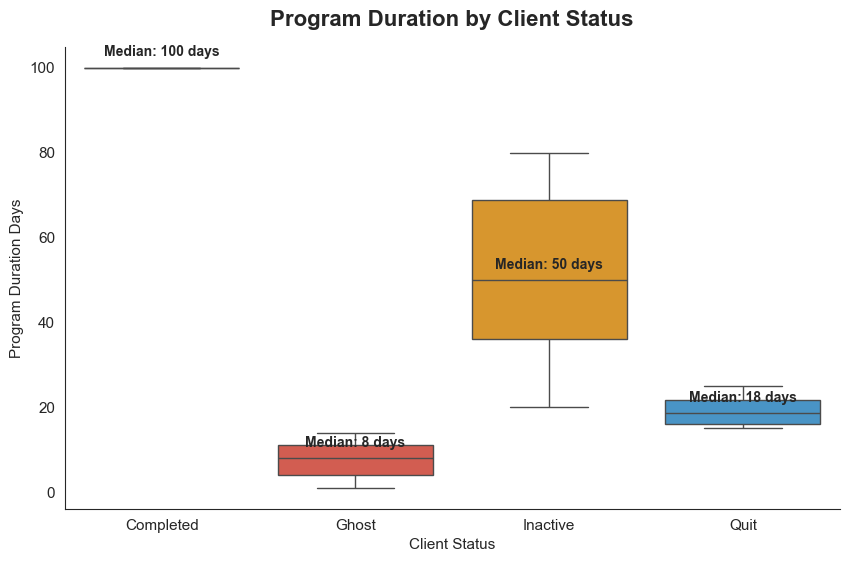

,Status,count,mean,median,min,max
0,Completed,2431,100.0,100.0,100,100
1,Ghost,253,7.6,8.0,1,14
2,Inactive,246,50.7,50.0,20,80
3,Quit,70,19.1,18.5,15,25


In [20]:
# ============================================================
# Chart 12: Program Duration by Status
# Business Question:
# How does program duration differ across completed, ghost, inactive, and quit clients?
# ============================================================

# ------------------------------------------------------------
# Step 1: Prepare data for the box plot
# ------------------------------------------------------------

# Keep only the statuses we want to compare
status_order = ["Completed", "Ghost", "Inactive", "Quit"]

# Filter dataset for valid statuses and non-missing program duration
duration_df = df[
    (df["Status"].isin(status_order)) &
    (df["Program_Duration_Days"].notna())
].copy()

# ------------------------------------------------------------
# Step 2: Create box plot
# ------------------------------------------------------------

# Create chart canvas
fig, ax = plt.subplots(figsize=(10, 6), facecolor=BACKGROUND)

# Create color mapping for each status
status_colors = {
    "Completed": PRIMARY,
    "Ghost": WARNING,
    "Inactive": ACCENT,
    "Quit": NEUTRAL
}

# Create box plot
sns.boxplot(
    data=duration_df,
    x="Status",
    y="Program_Duration_Days",
    hue="Status",
    order=status_order,
    palette=status_colors,
    legend=False,
    ax=ax
)

# ------------------------------------------------------------
# Step 3: Add median labels
# ------------------------------------------------------------

# Calculate median program duration by status
duration_medians = (
    duration_df.groupby("Status")["Program_Duration_Days"]
    .median()
    .reindex(status_order)
)

# Add median labels above each box
for i, status in enumerate(status_order):
    median_value = duration_medians.loc[status]
    
    ax.text(
        i,
        median_value + 2,
        f"Median: {median_value:.0f} days",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# ------------------------------------------------------------
# Step 4: Format chart
# ------------------------------------------------------------

# Add chart title
ax.set_title(
    "Program Duration by Client Status",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Add axis labels
ax.set_xlabel("Client Status", fontsize=11)
ax.set_ylabel("Program Duration Days", fontsize=11)

# Remove unnecessary chart borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Keep background clean
ax.set_facecolor(BACKGROUND)

# ------------------------------------------------------------
# Step 5: Save and display chart
# ------------------------------------------------------------

# Save chart inside 06_eda_charts folder
chart_path = charts_folder / "chart_12_program_duration_by_status.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=BACKGROUND
)

# Display chart
plt.show()

# ------------------------------------------------------------
# Step 6: Show summary table
# ------------------------------------------------------------

duration_summary = (
    duration_df.groupby("Status")["Program_Duration_Days"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(1)
    .reindex(status_order)
    .reset_index()
)

duration_summary